In [1]:
import polars as pl
from polars import col
import polars.selectors as cs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from IPython.display import display
#from libs.misc import *
#from libs.misc import load_and_clean_data
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#import matplotlib.pyplot as plt
#import seaborn as sns

/Users/a2251/Documents/IT_Dev/ujSem3/machineLearning/spark_airflow/chembl_env/lib/python3.12/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


Notatki z zajec:
- kolumna relation? (<,>,=) to wiadomo tylko =
- IC_50 vs (p)IC_50 - to jest to samo co standard_value vs pchembl_value
- outliers - MSE vs MAE 

Dla grafowych sieci uzyc pytorch i pytorch geometric

Znalezc range cech

Wersjonowanie datasetów

zastanowic sie czy wyciac duze molekuly - duze tzn ze maja duzo atomow i jesli maja male ic50 czyli standard value to zastanawoic sie czy nie wyciac bo obliczanie dla nich grafow moze byc bardzo obliczeniowo kosztowne

In [2]:
DB_PATH = 'db/chembl_selected_ds.parquet'

In [3]:
def fetch_chembl_activity_to_polars(target_id="CHEMBL203", activity_type="IC50"):
    activity = new_client.activity
    query = activity.filter(target_chembl_id=target_id).filter(standard_type=activity_type)
    
    print(f"Pobieranie danych dla celu: {target_id}...")
    data = list(query)

    if data:
        df = pl.DataFrame(data, infer_schema_length=None)
        
        # Konwersja standard_value na float (jeśli istnieje)
        if "standard_value" in df.columns:
             df = df.with_columns(
                pl.col("standard_value").cast(pl.Float64, strict=False)
            )
        
        return df
    else:
        print("Nie znaleziono danych.")
        return pl.DataFrame()

def get_data_from_parquet(file_path = "Chembl203_IC50.parquet"):
    if os.path.exists(file_path):
        print(f"Wczytywanie danych z pliku lokalnego: {file_path}")
        return pl.read_parquet(file_path)
    else:
        print(f"Plik nie istnieje: {file_path}")
        return None

        
def save_data_to_parquet(df, file_path = "Chembl203_IC50.parquet"):
    if df is not None:
        print(f"Zapisywanie danych do pliku: {file_path}")
        df.write_parquet(file_path)
    else:
        print("Nie ma danych do zapisania.")

# Uruchomienie


In [4]:
import polars as pl
from chembl_webresource_client.new_client import new_client

def fetch_chembl_data_with_properties(target_id="CHEMBL203", activity_type="IC50"):
    # 1. Pobieranie aktywności (Twój kod)
    print(f"Pobieranie aktywności dla celu: {target_id}...")
    activity_query = new_client.activity.filter(
        target_chembl_id=target_id, 
        standard_type=activity_type
    ).only(['molecule_chembl_id', 'standard_value', 'standard_units', 'pchembl_value'])
    
    act_data = list(activity_query)
    if not act_data:
        print("Nie znaleziono danych aktywności.")
        return pl.DataFrame()
    
    df_act = pl.DataFrame(act_data)

    # 2. Pobieranie właściwości cząsteczek (HBD, HBA, PSA)
    # Wyciągamy unikalne ID cząsteczek, żeby nie pytać o to samo dwa razy
    unique_mol_ids = df_act["molecule_chembl_id"].unique().to_list()
    
    print(f"Pobieranie właściwości dla {len(unique_mol_ids)} unikalnych cząsteczek...")
    mol_query = new_client.molecule.filter(
        molecule_chembl_id__in=unique_mol_ids
    ).only(['molecule_chembl_id', 'molecule_properties'])
    
    mol_data = list(mol_query)
    
    # 3. Tworzenie DataFrame z właściwościami i rozbijanie słownika na kolumny
    # Używamy Twojej prośby: wyciągamy do osobnych kolumn
    df_mol = pl.DataFrame(mol_data).with_columns([
        pl.col("molecule_properties").struct.field("hbd").alias("hbd"),
        pl.col("molecule_properties").struct.field("hba").alias("hba"),
        pl.col("molecule_properties").struct.field("psa").alias("psa"),
        pl.col("molecule_properties").struct.field("full_mwt").alias("mw")
    ]).drop("molecule_properties")

    # 4. Łączenie (Join) aktywności z właściwościami
    df_final = df_act.join(df_mol, on="molecule_chembl_id", how="left")

    # Konwersja typów (standard_value na float)
    if "standard_value" in df_final.columns:
        df_final = df_final.with_columns(
            pl.col("standard_value").cast(pl.Float64, strict=False)
        )

    return df_final
"""
# Uruchomienie
df = fetch_chembl_data_with_properties()
if not df.is_empty():
    save_data_to_parquet(df, "Chembl203_with_properties.parquet")
    print("Sukces: Dane z właściwościami zostały zapisane.")
print(df.head())
"""

'\n# Uruchomienie\ndf = fetch_chembl_data_with_properties()\nif not df.is_empty():\n    save_data_to_parquet(df, "Chembl203_with_properties.parquet")\n    print("Sukces: Dane z właściwościami zostały zapisane.")\nprint(df.head())\n'

In [5]:
df_molecule = get_data_from_parquet("Chembl203_with_properties.parquet")

Wczytywanie danych z pliku lokalnego: Chembl203_with_properties.parquet


In [6]:
df_molecule.head()

molecule_chembl_id,pchembl_value,standard_units,standard_value,units,value,hbd,hba,psa,mw
str,str,str,f64,str,str,i64,i64,str,str
"""CHEMBL68920""","""7.39""","""nM""",41.0,"""uM""","""0.041""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""6.52""","""nM""",300.0,"""uM""","""0.3""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""5.11""","""nM""",7820.0,"""uM""","""7.82""",3,4,"""82.70""","""383.81"""
"""CHEMBL69960""","""6.77""","""nM""",170.0,"""uM""","""0.17""",3,6,"""112.24""","""482.90"""
"""CHEMBL69960""","""7.40""","""nM""",40.0,"""uM""","""0.04""",3,6,"""112.24""","""482.90"""


In [7]:
df_activity = get_data_from_parquet()

if df_activity.is_empty():
    df_activity = fetch_chembl_activity_to_polars()
    save_data_to_parquet(df_activity)


Wczytywanie danych z pliku lokalnego: Chembl203_IC50.parquet


In [8]:
df_final = df_activity.join(df_molecule, on="molecule_chembl_id", how="left")
print(f"Pobrano {len(df_final)} wierszy.")

Pobrano 291234 wierszy.


In [9]:
df_final.head()


action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value,pchembl_value_right,standard_units_right,standard_value_right,units_right,value_right,hbd,hba,psa,mw
struct[3],str,i64,list[struct[12]],str,str,str,str,str,str,str,str,str,str,str,str,str,i64,struct[4],str,str,str,str,i64,str,i64,str,i64,i64,str,str,str,str,null,f64,str,str,str,str,str,null,str,str,str,str,str,str,str,f64,str,str,i64,i64,str,str
null,null,32260,[],"""CHEMBL674637""","""Inhibitory activity towards ty…","""B""",null,null,"""BAO_0000190""","""BAO_0000357""","""single protein format""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",null,null,"""CHEMBL1134862""","""Bioorg Med Chem Lett""",2002,"{""19.25"",""0.37"",""2.94"",""8.93""}","""CHEMBL68920""",null,"""CHEMBL68920""","""7.39""",0,"""http://www.openphacts.org/unit…",119482,"""=""",1,1,"""=""",null,"""IC50""","""nM""",null,41.0,"""CHEMBL203""","""Homo sapiens""","""Epidermal growth factor recept…","""9606""",null,null,"""IC50""","""uM""","""UO_0000065""",null,"""0.041""","""7.39""","""nM""",41.0,"""uM""","""0.041""",3,4,"""82.70""","""383.81"""
null,null,32260,[],"""CHEMBL674637""","""Inhibitory activity towards ty…","""B""",null,null,"""BAO_0000190""","""BAO_0000357""","""single protein format""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",null,null,"""CHEMBL1134862""","""Bioorg Med Chem Lett""",2002,"{""19.25"",""0.37"",""2.94"",""8.93""}","""CHEMBL68920""",null,"""CHEMBL68920""","""7.39""",0,"""http://www.openphacts.org/unit…",119482,"""=""",1,1,"""=""",null,"""IC50""","""nM""",null,41.0,"""CHEMBL203""","""Homo sapiens""","""Epidermal growth factor recept…","""9606""",null,null,"""IC50""","""uM""","""UO_0000065""",null,"""0.041""","""6.52""","""nM""",300.0,"""uM""","""0.3""",3,4,"""82.70""","""383.81"""
null,null,32260,[],"""CHEMBL674637""","""Inhibitory activity towards ty…","""B""",null,null,"""BAO_0000190""","""BAO_0000357""","""single protein format""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",null,null,"""CHEMBL1134862""","""Bioorg Med Chem Lett""",2002,"{""19.25"",""0.37"",""2.94"",""8.93""}","""CHEMBL68920""",null,"""CHEMBL68920""","""7.39""",0,"""http://www.openphacts.org/unit…",119482,"""=""",1,1,"""=""",null,"""IC50""","""nM""",null,41.0,"""CHEMBL203""","""Homo sapiens""","""Epidermal growth factor recept…","""9606""",null,null,"""IC50""","""uM""","""UO_0000065""",null,"""0.041""","""5.11""","""nM""",7820.0,"""uM""","""7.82""",3,4,"""82.70""","""383.81"""
null,null,32263,[],"""CHEMBL621151""","""Inhibition of autophosphorylat…","""F""",null,null,"""BAO_0000190""","""BAO_0000219""","""cell-based format""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",null,null,"""CHEMBL1134862""","""Bioorg Med Chem Lett""",2002,null,"""CHEMBL68920""",null,"""CHEMBL68920""","""6.52""",0,"""http://www.openphacts.org/unit…",119482,"""=""",1,1,"""=""",null,"""IC50""","""nM""",null,300.0,"""CHEMBL203""","""Homo sapiens""","""Epidermal growth factor recept…","""9606""",null,null,"""IC50""","""uM""","""UO_0000065""",null,"""0.3""","""7.39""","""nM""",41.0,"""uM""","""0.041""",3,4,"""82.70""","""383.81"""
null,null,32263,[],"""CHEMBL621151""","""Inhibition of autophosphorylat…","""F""",null,null,"""BAO_0000190""","""BAO_0000219""","""cell-based format""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",null,null,"""CHEMBL1134862""","""Bioorg Med Chem Lett""",2002,null,"""CHEMBL68920""",null,"""CHEMBL68920""","""6.52""",0,"""http://www.openphac

In [10]:
save_data_to_parquet(df_final, "Chembl203_with_molecule_and_activity.parquet")

Zapisywanie danych do pliku: Chembl203_with_molecule_and_activity.parquet


In [11]:
# 1. Ustawienie konfiguracji (globalnie dla sesji)
pl.Config.set_tbl_cols(50)       # Pokazuj do 50 kolumn
pl.Config.set_tbl_width_chars(2000) # Zwiększ szerokość wyświetlania w konsoli

# 2. Wyświetlenie DataFrame
print(f"Pobrano {len(df_activity)} wierszy.")
print(df_activity.head())
print(f"Kształt danych: {df_activity.shape}")

Pobrano 25758 wierszy.
shape: (5, 46)
┌─────────────┬──────────────────┬─────────────┬─────────────────────┬─────────────────┬─────────────────────────────────┬────────────┬─────────────────────────┬────────────────────────┬──────────────┬─────────────┬───────────────────────┬─────────────────────────────────┬───────────────────────┬───────────────────────────┬────────────────────┬──────────────────────┬───────────────┬────────────────────────────────┬────────────────────┬────────────────────┬───────────────────────────┬───────────────┬─────────────────────┬─────────────────────────────────┬───────────┬──────────┬────────┬───────────────┬───────────────────┬─────────────────────┬───────────────┬────────────────┬──────────────────────┬────────────────┬──────────────────┬─────────────────┬─────────────────────────────────┬───────────────┬────────────┬──────┬──────┬───────┬────────────┬─────────────┬───────┐
│ action_type ┆ activity_comment ┆ activity_id ┆ activity_properties ┆ assay_chem

In [12]:
def analyze_and_drop_correlated(df: pl.DataFrame, threshold=0.8) -> pl.DataFrame:
    """
    Analiza korelacji (Polars): Heatmapa, wypisanie par, usuwanie skorelowanych cech.
    """
    # W Polars operacje są zazwyczaj 'lazy' lub zwracają nowe obiekty,
    # ale dla bezpieczeństwa można zrobić clone, jeśli planujemy modyfikacje wewnątrz (choć tu zwracamy nowy df).
    df_clean = df.clone()

    # Wybieramy tylko kolumny numeryczne za pomocą selektorów
    numeric_df = df_clean.select(cs.numeric())

    if numeric_df.is_empty() or len(numeric_df.columns) < 2:
        print("   -> Zbyt mało kolumn numerycznych do analizy korelacji.")
        return df_clean

    # 1. Obliczanie macierzy korelacji
    corr_df = numeric_df.corr()

    # Przygotowanie danych do Heatmapy
    # Musimy przypisać nazwy kolumn jako indeks w Pandas, aby heatmapa miała etykiety
    corr_pandas = corr_df.to_pandas()
    corr_pandas.index = numeric_df.columns

    plt.figure(figsize=(12, 10))
    plt.title('Correlation Matrix')
    sns.heatmap(corr_pandas, linewidths=0.1, cmap='RdYlGn', annot=False)
    plt.show()
    print("   -> Wyświetlono heatmapę korelacji.")

    # 2. Znalezienie silnie skorelowanych par
    # W Polars nie używamy maskowania trójkąta (triu).
    # Zamiast tego robimy 'unpivot' (melt) i filtrujemy.

    # Dodajemy kolumnę z nazwami zmiennych (bo Polars nie ma indeksu)
    feature_names = numeric_df.columns

    long_corr = (
        corr_df
        .with_columns(pl.Series("var1", feature_names)) # Dodajemy nazwę wiersza
        .unpivot(index="var1", variable_name="var2", value_name="correlation") # Spłaszczamy macierz
    )

    # Filtrowanie:
    # 1. Usuwamy autokorelacje i duplikaty par (bierzemy tylko gdzie var1 < var2, to symuluje górny trójkąt)
    # 2. Bierzemy wartość bezwzględną korelacji > threshold
    high_corr_pairs = long_corr.filter(
        (pl.col("var1") < pl.col("var2")) &
        (pl.col("correlation").abs() > threshold)
    ).sort("correlation", descending=True)

    if not high_corr_pairs.is_empty():
        print(f"\n   Pary cech o korelacji powyżej {threshold}:")
        print(high_corr_pairs)

        # 3. Usuwanie cech (Automatyczne)
        # Strategia: Z pary (var1, var2) usuwamy var2 (tę "drugą" w kolejności, podobnie jak w logice Pandas upper_tri)

        potential_drop = high_corr_pairs.select("var2").unique().to_series().to_list()

        # Specjalna ochrona dla targetów
        protected_cols = ['is_active', 'pchembl_value', 'standard_value']
        to_drop = [col for col in potential_drop if col not in protected_cols]

        if to_drop:
            print(f"\n   -> Usuwanie {len(to_drop)} silnie skorelowanych cech: {to_drop}")
            df_clean = df_clean.drop(to_drop)
        else:
            print("   -> Znaleziono silne korelacje, ale dotyczą kolumn chronionych (targetów). Nie usuwam.")
    else:
        print("   -> Brak cech o korelacji powyżej progu.")

    return df_clean

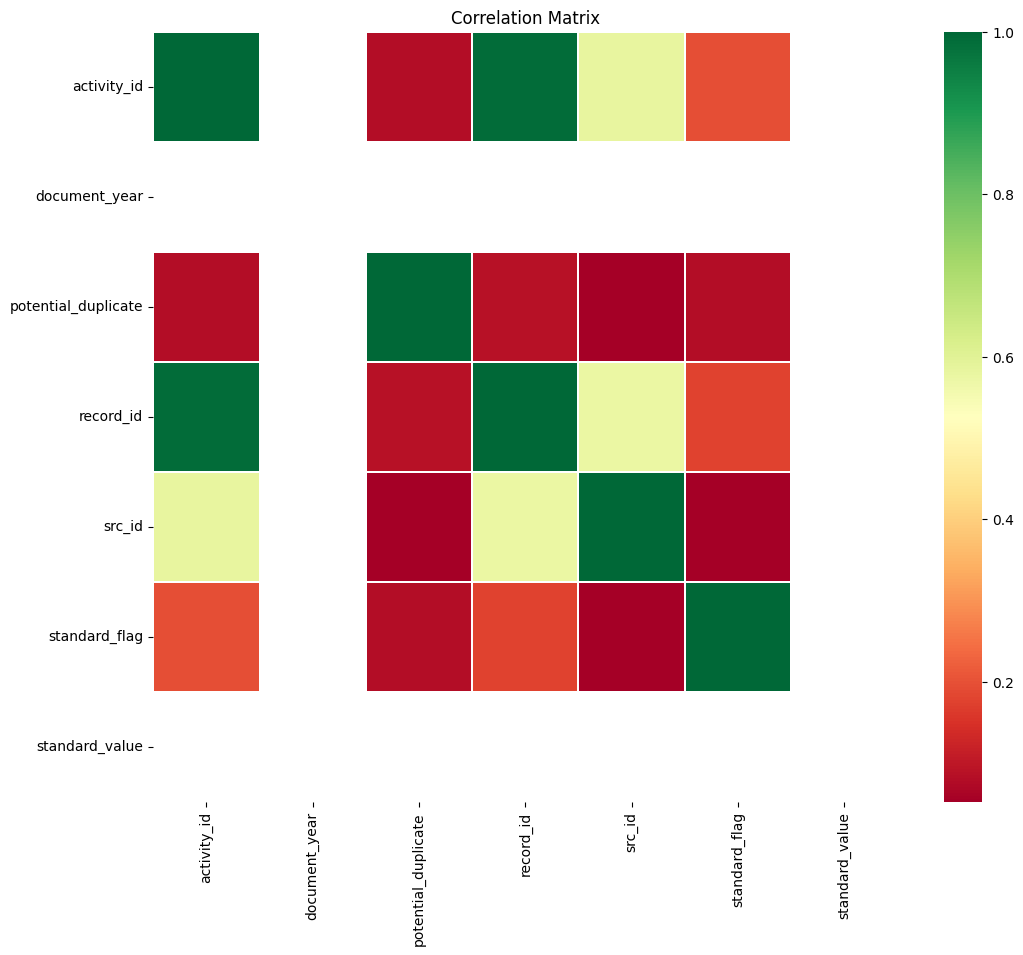

   -> Wyświetlono heatmapę korelacji.

   Pary cech o korelacji powyżej 0.9:
shape: (12, 3)
┌─────────────────────┬─────────────────────┬─────────────┐
│ var1                ┆ var2                ┆ correlation │
│ ---                 ┆ ---                 ┆ ---         │
│ str                 ┆ str                 ┆ f64         │
╞═════════════════════╪═════════════════════╪═════════════╡
│ activity_id         ┆ document_year       ┆ NaN         │
│ document_year       ┆ potential_duplicate ┆ NaN         │
│ document_year       ┆ record_id           ┆ NaN         │
│ document_year       ┆ src_id              ┆ NaN         │
│ document_year       ┆ standard_flag       ┆ NaN         │
│ …                   ┆ …                   ┆ …           │
│ potential_duplicate ┆ standard_value      ┆ NaN         │
│ record_id           ┆ standard_value      ┆ NaN         │
│ src_id              ┆ standard_value      ┆ NaN         │
│ standard_flag       ┆ standard_value      ┆ NaN         │
│ activi

In [13]:
df_cleaned = analyze_and_drop_correlated(df_activity, threshold=0.90)

Dane na temat nulli w kolumnach:
shape: (1, 46)
┌─────────────┬──────────────────┬─────────────┬─────────────────────┬─────────────────┬───────────────────┬────────────┬─────────────────────────┬────────────────────────┬──────────────┬────────────┬───────────┬──────────────────┬───────────────────────┬───────────────────────────┬────────────────────┬──────────────────┬───────────────┬───────────────────┬────────────────────┬────────────────────┬───────────────────────────┬───────────────┬─────────────────────┬────────────┬───────────┬──────────┬────────┬───────────────┬───────────────────┬─────────────────────┬───────────────┬────────────────┬──────────────────────┬────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────┬────────────┬───────┬──────┬───────┬──────────┬─────────────┬───────┐
│ action_type ┆ activity_comment ┆ activity_id ┆ activity_properties ┆ assay_chembl_id ┆ assay_description ┆ assay_type ┆ assay_variant_accession ┆ assay_variant_mutat

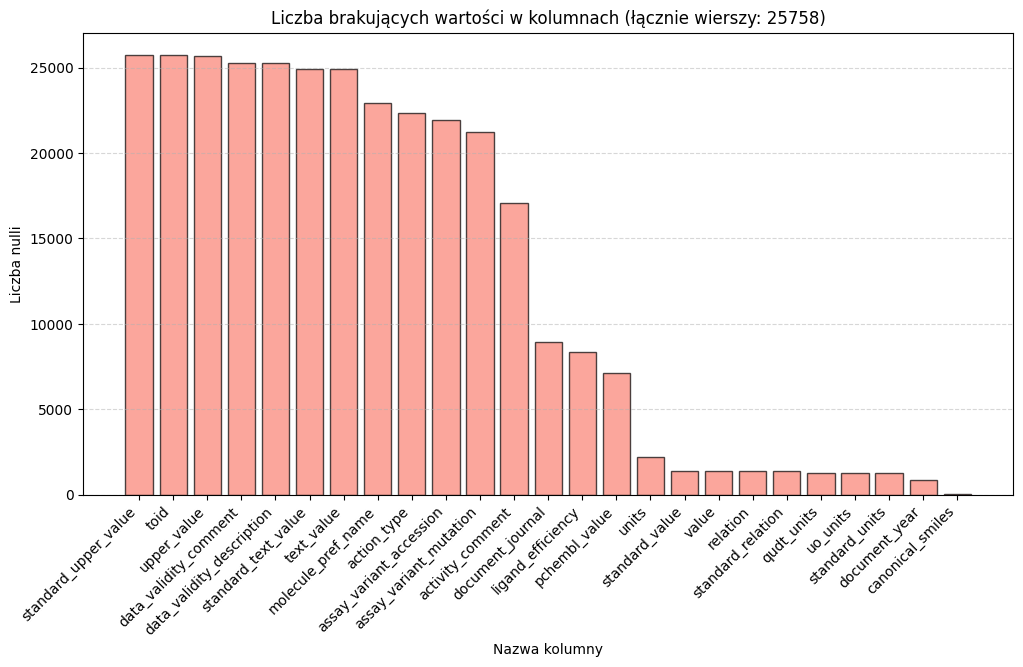

In [14]:
# Sprawdzanie nulli
nulls = df_activity.null_count().to_dicts()[0]


filtered_nulls = {k: v for k, v in nulls.items() if v > 0}
sorted_nulls = dict(sorted(filtered_nulls.items(), key=lambda item: item[1], reverse=True))

columns = list(sorted_nulls.keys())
counts = list(sorted_nulls.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(columns, counts, color='salmon', edgecolor='black', alpha=0.7)

plt.title(f'Liczba brakujących wartości w kolumnach (łącznie wierszy: {len(df_activity)})')
plt.xlabel('Nazwa kolumny')
plt.ylabel('Liczba nulli')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

print("Dane na temat nulli w kolumnach:")
print(df_activity.null_count())
plt.show()

Wydzielamy najbardziej istotne kolumny do analizy:
- molecule_chembl_id - identyfikator molu
- canonical_smiles - struktura molu
- standard_value - wartosc 
- standard_units - jednostki 
- standard_relation - relacja standardu (<, >, =)   ">" oznacza większą wartość ni udało się zbadać
- pchembl_value - wartosc pchembl obliczona jako -log10(standard_value)

In [15]:
# Przykład w Polars
df_activity_high_importance = df_final.select([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "standard_relation",
    "pchembl_value",
    "hbd",
    "hba",
    "psa",
    "mw"
])
df_activity_high_importance

molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation,pchembl_value,hbd,hba,psa,mw
str,str,f64,str,str,str,i64,i64,str,str
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",41.0,"""nM""","""=""","""7.39""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",41.0,"""nM""","""=""","""7.39""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",41.0,"""nM""","""=""","""7.39""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",300.0,"""nM""","""=""","""6.52""",3,4,"""82.70""","""383.81"""
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",300.0,"""nM""","""=""","""6.52""",3,4,"""82.70""","""383.81"""
…,…,…,…,…,…,…,…,…,…
"""CHEMBL6037592""","""CC(Nc1c(C#N)cnc2ccc(-c3cnc(Cl)…",200.0,"""nM""",""">""",null,2,6,"""107.77""","""495.97"""
"""CHEMBL6063877""","""C[C@@H](Nc1ncnc2ccc(-c3cnc(Cl)…",110.0,"""nM""","""=""","""6.96""",2,6,"""96.87""","""471.95"""
"""CHEMBL6024030""","""C[C@H](Nc1ncnc2ccc(-c3cnc(Cl)c…",200.0,"""nM""",""">""",null,2,6,"""96.87""","""471.95"""


Sprawdzam jesnostki dla danych moli

In [16]:
# Sprawdźmy brakujące wartości, będzimy musieli odrzucić te wiersze w których są brakujące wartości standard_value
print("Brakujące wartości:")
print(df_activity_high_importance.null_count())

# 2. Sprawdźmy jednostki - czy są spójne?
print("\nRozkład jednostek:")
print(df_activity_high_importance["standard_units"].value_counts())

# 3. Sprawdźmy relacje - czy mamy same '='?
print("\nTypy relacji:")
print(df_activity_high_importance["standard_relation"].value_counts())

Brakujące wartości:
shape: (1, 10)
┌────────────────────┬──────────────────┬────────────────┬────────────────┬───────────────────┬───────────────┬──────┬──────┬──────┬─────┐
│ molecule_chembl_id ┆ canonical_smiles ┆ standard_value ┆ standard_units ┆ standard_relation ┆ pchembl_value ┆ hbd  ┆ hba  ┆ psa  ┆ mw  │
│ ---                ┆ ---              ┆ ---            ┆ ---            ┆ ---               ┆ ---           ┆ ---  ┆ ---  ┆ ---  ┆ --- │
│ u32                ┆ u32              ┆ u32            ┆ u32            ┆ u32               ┆ u32           ┆ u32  ┆ u32  ┆ u32  ┆ u32 │
╞════════════════════╪══════════════════╪════════════════╪════════════════╪═══════════════════╪═══════════════╪══════╪══════╪══════╪═════╡
│ 0                  ┆ 47               ┆ 4392           ┆ 4173           ┆ 4386              ┆ 45291         ┆ 1005 ┆ 1005 ┆ 1005 ┆ 26  │
└────────────────────┴──────────────────┴────────────────┴────────────────┴───────────────────┴───────────────┴──────┴──────┴──────

####Prezentacja roznicy rozkladu standard value i pchembl_value

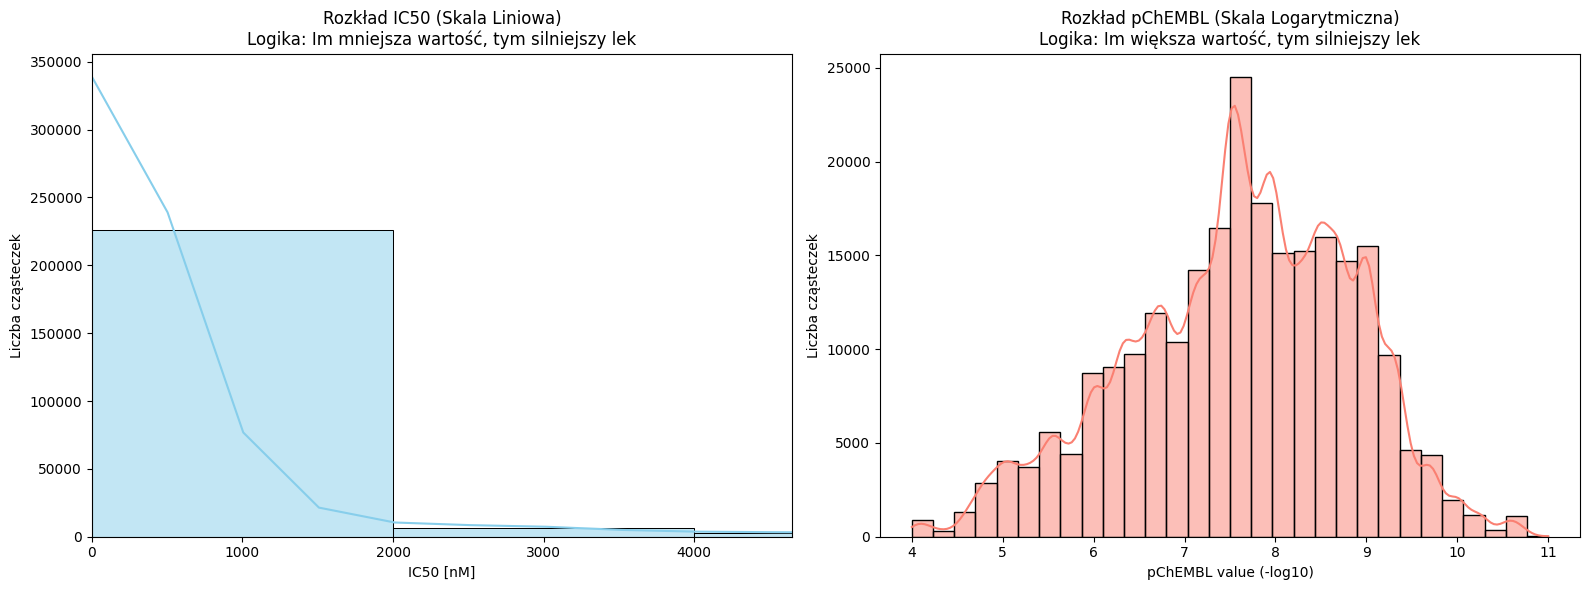

Liczba cząsteczek użytych do wykresu: 245943


In [17]:


# 2. Wstępne czyszczenie do wykresu:
# - bierzemy tylko pewne pomiary (=)
# - bierzemy tylko jednostki nM, żeby skala była spójna
# - usuwamy puste wartości w kluczowych kolumnach
plot_df = df_activity_high_importance.filter(
    (pl.col("standard_relation") == "=") & 
    (pl.col("standard_units") == "nM")
).select([
    pl.col("standard_value").cast(pl.Float64),
    pl.col("pchembl_value").cast(pl.Float64)
]).drop_nulls()

# 3. Tworzymy dwa wykresy obok siebie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram 1: Surowe IC50 (Skala liniowa)
sns.histplot(plot_df["standard_value"], bins=50, ax=ax1, color='skyblue', kde=True)
ax1.set_title("Rozkład IC50 (Skala Liniowa)\nLogika: Im mniejsza wartość, tym silniejszy lek")
ax1.set_xlabel("IC50 [nM]")
ax1.set_ylabel("Liczba cząsteczek")
# Ograniczamy widok X, bo outlierzy (np. 100 000 nM) zepsują czytelność
ax1.set_xlim(0, plot_df["standard_value"].quantile(0.95)) 

# Histogram 2: pChEMBL (Skala logarytmiczna)
sns.histplot(plot_df["pchembl_value"], bins=30, ax=ax2, color='salmon', kde=True)
ax2.set_title("Rozkład pChEMBL (Skala Logarytmiczna)\nLogika: Im większa wartość, tym silniejszy lek")
ax2.set_xlabel("pChEMBL value (-log10)")
ax2.set_ylabel("Liczba cząsteczek")

plt.tight_layout()
plt.show()

# Dodatkowe info o statystykach
print(f"Liczba cząsteczek użytych do wykresu: {len(plot_df)}")

In [18]:
# Wybieramy szerszy zestaw kolumn do analizy EDA
eda_df = df_activity.select([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units",
    "standard_relation",
    "pchembl_value",
    "assay_description" # Opis testu - kluczowy przy outlierach!
]).filter(
    (pl.col("standard_relation") == "=") & 
    (pl.col("standard_units") == "nM")
).with_columns([
    pl.col("standard_value").cast(pl.Float64).alias("IC50"),
    pl.col("pchembl_value").cast(pl.Float64).alias("pIC50")
]).drop_nulls(subset=["IC50", "pIC50", "canonical_smiles"])

print(f"Dane po wstępnym odchudzeniu: {eda_df.shape}")

Dane po wstępnym odchudzeniu: (18633, 9)


In [19]:
eda_df

molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation,pchembl_value,assay_description,IC50,pIC50
str,str,f64,str,str,str,str,f64,f64
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",41.0,"""nM""","""=""","""7.39""","""Inhibitory activity towards ty…",41.0,7.39
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",300.0,"""nM""","""=""","""6.52""","""Inhibition of autophosphorylat…",300.0,6.52
"""CHEMBL68920""","""Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(N…",7820.0,"""nM""","""=""","""5.11""","""Inhibition of ligand-induced p…",7820.0,5.11
"""CHEMBL69960""","""Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C…",170.0,"""nM""","""=""","""6.77""","""Inhibitory activity towards ty…",170.0,6.77
"""CHEMBL69960""","""Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C…",40.0,"""nM""","""=""","""7.40""","""Inhibition of autophosphorylat…",40.0,7.4
…,…,…,…,…,…,…,…,…
"""CHEMBL5971875""","""C[C@@H](Nc1c(C#N)cnc2ccc(-c3cn…",11.0,"""nM""","""=""","""7.96""","""Z′-LYTE Biochemical Aassay: Z′…",11.0,7.96
"""CHEMBL5982623""","""CC(Nc1c(C#N)cnc2ccc(-c3cnc4[nH…",11.0,"""nM""","""=""","""7.96""","""Z′-LYTE Biochemical Aassay: Z′…",11.0,7.96
"""CHEMBL6063877""","""C[C@@H](Nc1ncnc2ccc(-c3cnc(Cl)…",110.0,"""nM""","""=""","""6.96""","""Z′-LYTE Biochemical Aassay: Z′…",110.0,6.96


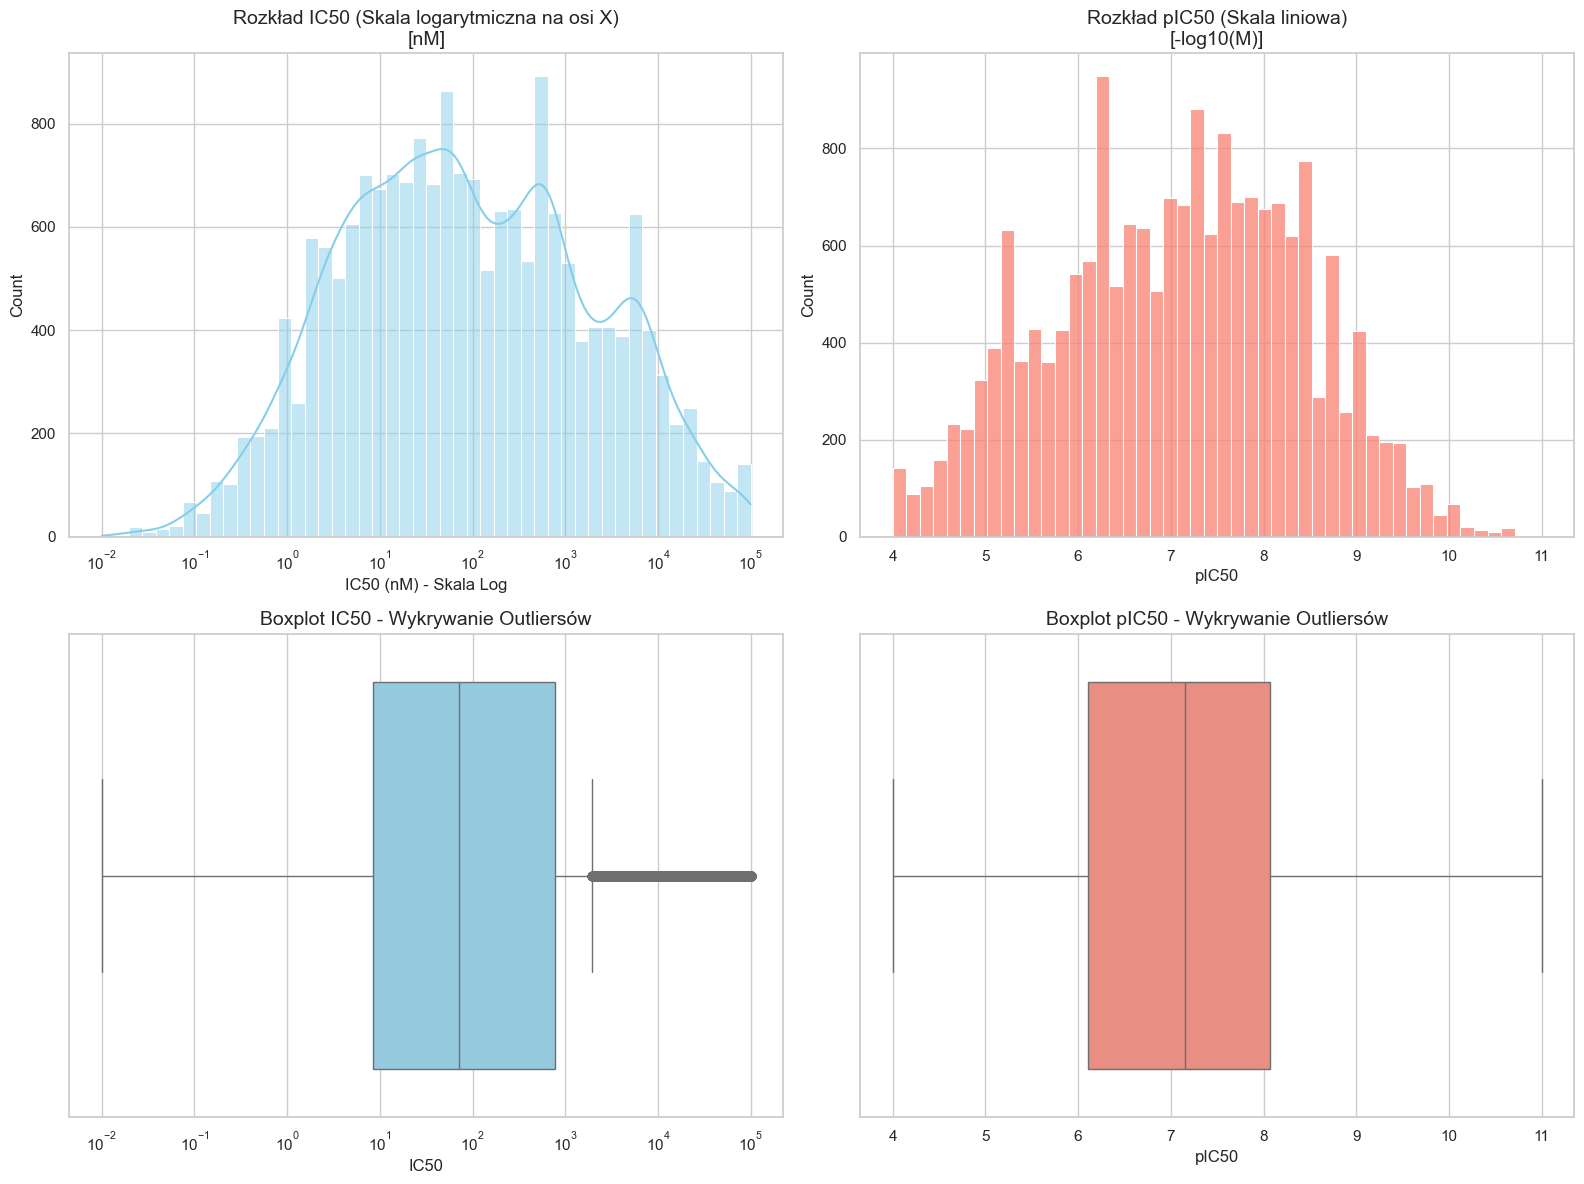

Zakres IC50: 0.0100 - 100000.00 nM
Zakres pIC50: 4.00 - 11.00


In [20]:

# 1. Przygotowanie danych (założenie: masz już załadowany df z poprzedniego kroku)
# Filtrujemy dane, aby wykresy były rzetelne
plot_df = eda_df.filter(
    (pl.col("standard_relation") == "=") & 
    (pl.col("standard_units") == "nM")
).select([
    pl.col("IC50"),
    pl.col("pIC50")
]).drop_nulls()

# 2. Ustawienia stylu
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- RZĄD 1: HISTOGRAMY (ROZKŁAD) ---

# Histogram IC50 (Logika: im bliżej 0, tym lepiej)
# Używamy skali log10 dla osi X, bo surowe IC50 ma zazwyczaj gigantyczny "ogon"
sns.histplot(plot_df["IC50"], kde=True, ax=axes[0, 0], color="skyblue", log_scale=True)
axes[0, 0].set_title("Rozkład IC50 (Skala logarytmiczna na osi X)\n[nM]", fontsize=14)
axes[0, 0].set_xlabel("IC50 (nM) - Skala Log")

# Histogram pIC50 (Logika: im wyżej, tym lepiej)
sns.histplot(plot_df["pIC50"], kde=False, ax=axes[0, 1], color="salmon")
axes[0, 1].set_title("Rozkład pIC50 (Skala liniowa)\n[-log10(M)]", fontsize=14)
axes[0, 1].set_xlabel("pIC50")

# --- RZĄD 2: BOXPLOTY (OUTLIERZY) ---

# Boxplot IC50
sns.boxplot(x=plot_df["IC50"], ax=axes[1, 0], color="skyblue")
axes[1, 0].set_xscale("log") # Skala logarytmiczna, żeby zobaczyć outliersy po obu stronach
axes[1, 0].set_title("Boxplot IC50 - Wykrywanie Outliersów", fontsize=14)

# Boxplot pIC50
sns.boxplot(x=plot_df["pIC50"], ax=axes[1, 1], color="salmon")
axes[1, 1].set_title("Boxplot pIC50 - Wykrywanie Outliersów", fontsize=14)

plt.tight_layout()
plt.show()

# 3. Wyświetlenie konkretnych liczb
print(f"Zakres IC50: {plot_df['IC50'].min():.4f} - {plot_df['IC50'].max():.2f} nM")
print(f"Zakres pIC50: {plot_df['pIC50'].min():.2f} - {plot_df['pIC50'].max():.2f}")

#### Szukanie Oulierów (p)IC_50

In [21]:
q1 = eda_df["pIC50"].quantile(0.25)
q3 = eda_df["pIC50"].quantile(0.75)
iqr = q3 - q1
threshold_high = q3 + 1.5 * iqr

print(f"Statystyki pIC50:")
print(f"  Q3: {q3:.2f} | IQR: {iqr:.2f}")
print(f"  Próg dla outlierów: {threshold_high:.2f}")

# --- KROK 2: Filtrowanie i sortowanie (Wersja Polars) ---
# Zamiast [], używamy .filter() oraz .sort()
hits_df = eda_df.filter(pl.col("pIC50") > threshold_high).sort("pIC50", descending=True)

num_hits = len(hits_df)
print(f"Znaleziono {num_hits} cząsteczek powyżej progu.")

Statystyki pIC50:
  Q3: 8.07 | IQR: 1.96
  Próg dla outlierów: 11.01
Znaleziono 0 cząsteczek powyżej progu.


--- Statystyki opisowe dla deskryptorów ---


,hbd,hba,psa,mw
count,245133.00,245133.00,245133.00,245133.00
mean,1.65,7.38,84.38,473.18
std,0.71,1.17,18.22,71.14
min,0.00,0.00,3.88,110.11
25%,1.00,7.00,68.74,446.91
50%,2.00,7.00,87.55,472.59
75%,2.00,8.00,88.61,499.62
max,9.00,18.00,272.98,1061.10


/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_11501/1651061224.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=props_pd["hbd"], ax=axes[1, 0], palette="Blues")
/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_11501/1651061224.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=props_pd["hba"], ax=axes[1, 1], palette="Greens")


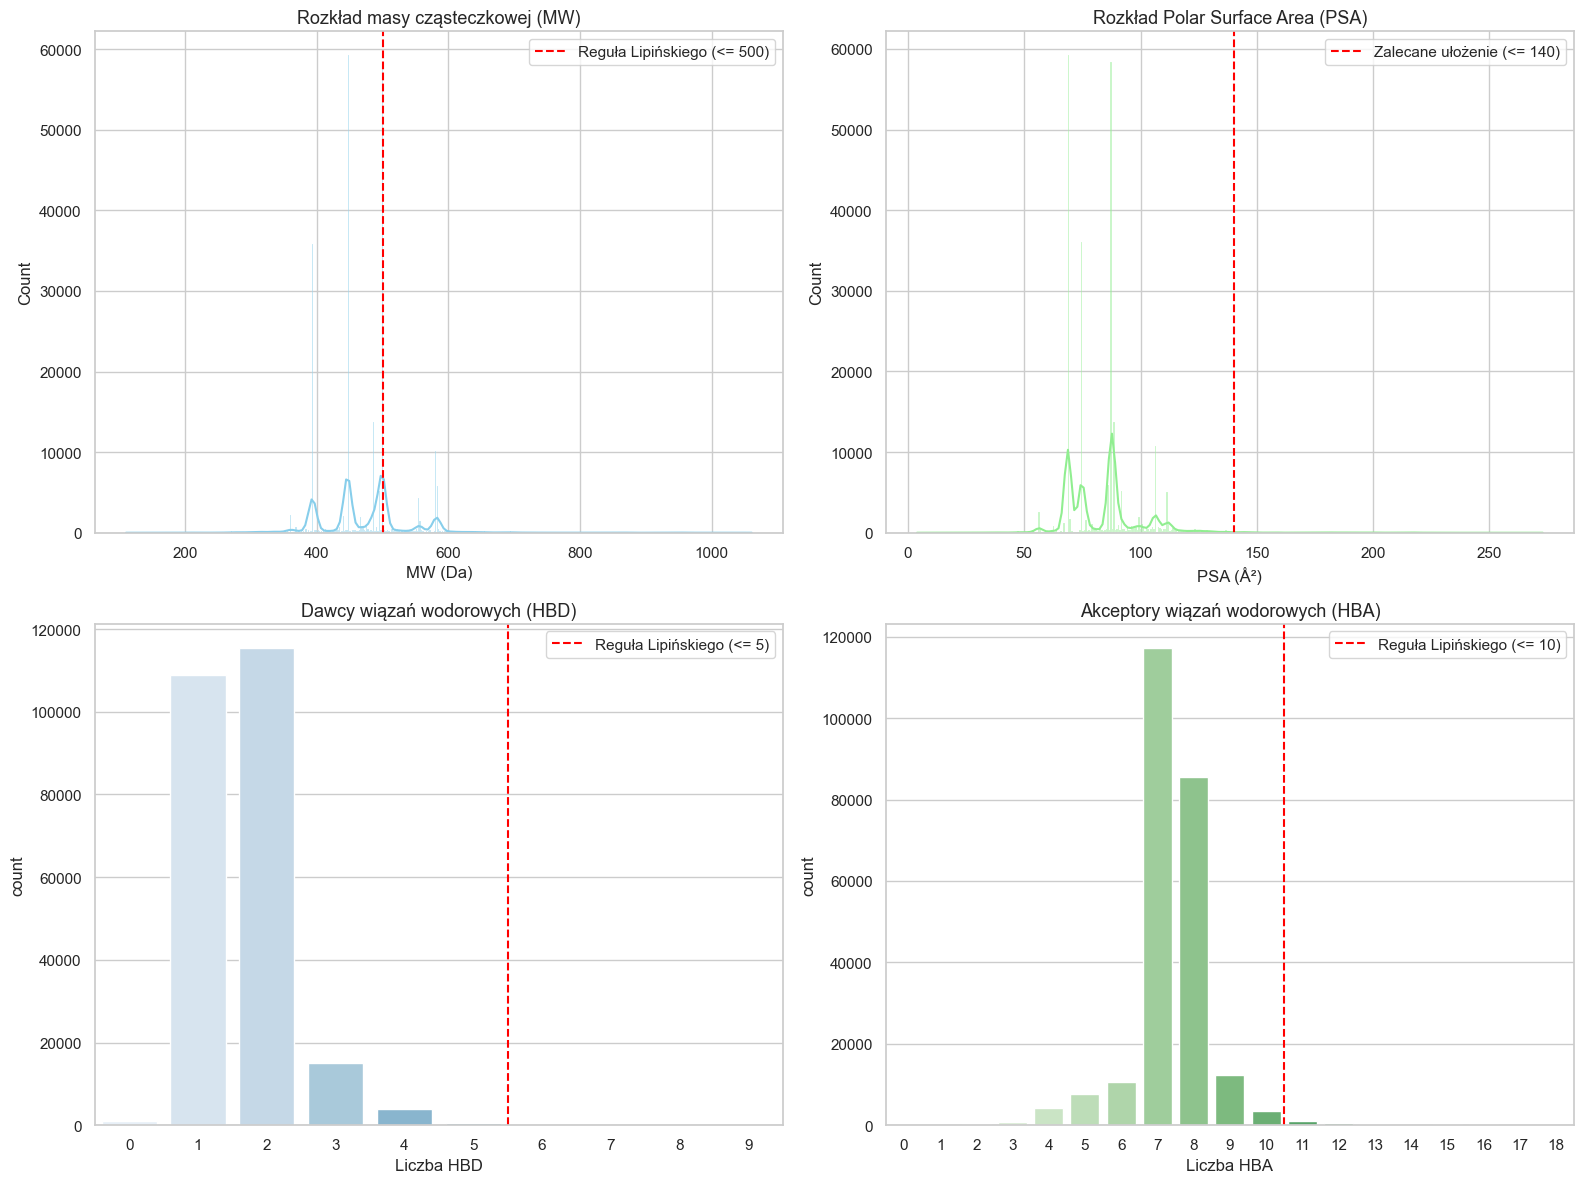

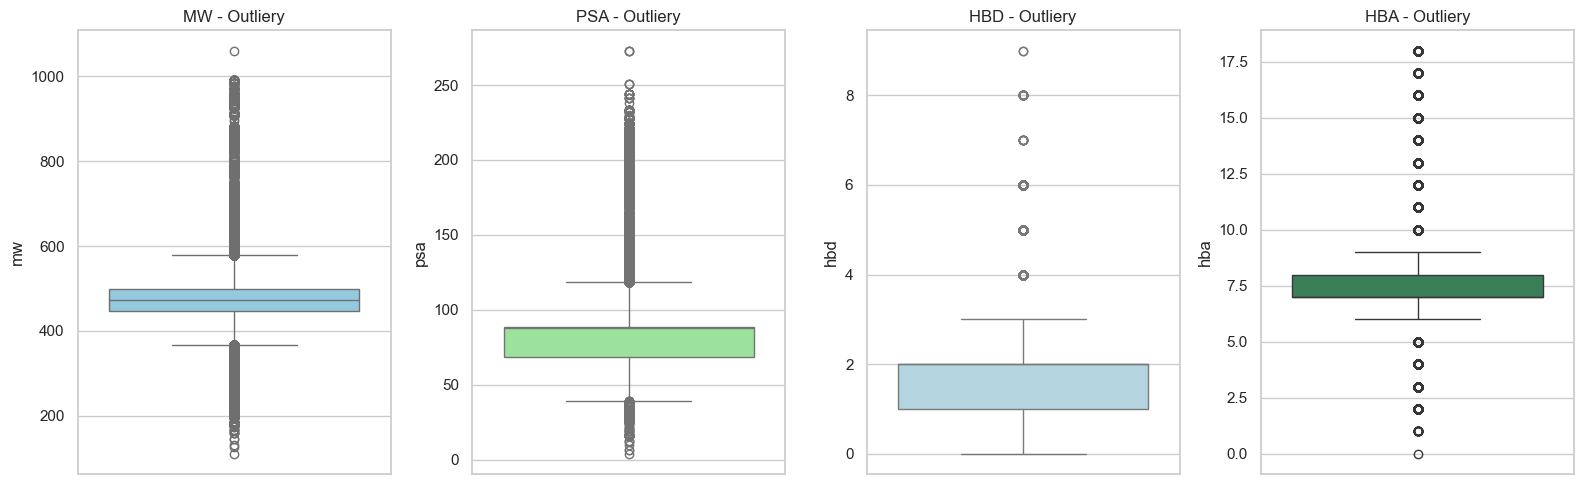


--- Korelacja deskryptorów z pIC50 ---


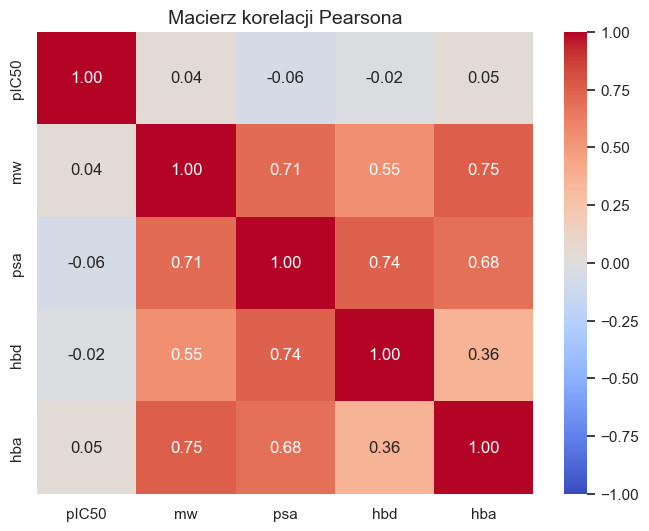

In [26]:
# Upewniamy się, że mamy potrzebne biblioteki
from IPython.display import display

# 1. Wybieramy dane z df_final i rzutujemy typy tekstowe (PSA, MW) na numeryczne
props_df = df_final.select([
    "molecule_chembl_id", 
    "pchembl_value", 
    "hbd", 
    "hba", 
    "psa", 
    "mw"
]).drop_nulls(subset=["pchembl_value"])

props_df = props_df.with_columns([
    pl.col("pchembl_value").cast(pl.Float64, strict=False).alias("pIC50"),
    pl.col("hbd").cast(pl.Int64, strict=False),
    pl.col("hba").cast(pl.Int64, strict=False),
    pl.col("psa").cast(pl.Float64, strict=False),
    pl.col("mw").cast(pl.Float64, strict=False)
]).drop_nulls()

# Przechodzimy na format Pandas do łatwiejszego generowania podsumowań i plotowania
props_pd = props_df.to_pandas()

print("--- Statystyki opisowe dla deskryptorów ---")
display(props_pd[["hbd", "hba", "psa", "mw"]].describe().round(2))

# 2. Wykresy rozkładów dla poszczególnych wskaźników
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MW (Masa cząsteczkowa)
sns.histplot(props_pd["mw"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Rozkład masy cząsteczkowej (MW)", fontsize=13)
axes[0, 0].set_xlabel("MW (Da)")
axes[0, 0].axvline(500, color='red', linestyle='--', label='Reguła Lipińskiego (<= 500)')
axes[0, 0].legend()

# PSA (Polar Surface Area)
sns.histplot(props_pd["psa"], kde=True, ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_title("Rozkład Polar Surface Area (PSA)", fontsize=13)
axes[0, 1].set_xlabel("PSA (Å²)")
axes[0, 1].axvline(140, color='red', linestyle='--', label='Zalecane ułożenie (<= 140)')
axes[0, 1].legend()

# HBD (Dawcy wiązań wodorowych)
sns.countplot(x=props_pd["hbd"], ax=axes[1, 0], palette="Blues")
axes[1, 0].set_title("Dawcy wiązań wodorowych (HBD)", fontsize=13)
axes[1, 0].set_xlabel("Liczba HBD")
axes[1, 0].axvline(5.5, color='red', linestyle='--', label='Reguła Lipińskiego (<= 5)')
axes[1, 0].legend()

# HBA (Akceptory wiązań wodorowych)
sns.countplot(x=props_pd["hba"], ax=axes[1, 1], palette="Greens")
axes[1, 1].set_title("Akceptory wiązań wodorowych (HBA)", fontsize=13)
axes[1, 1].set_xlabel("Liczba HBA")
axes[1, 1].axvline(10.5, color='red', linestyle='--', label='Reguła Lipińskiego (<= 10)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 3. Wykresy typu Boxplot (Wykrywanie Wartości Odstających)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
sns.boxplot(y=props_pd["mw"], ax=axes[0], color="skyblue").set_title("MW - Outliery")
sns.boxplot(y=props_pd["psa"], ax=axes[1], color="lightgreen").set_title("PSA - Outliery")
sns.boxplot(y=props_pd["hbd"], ax=axes[2], color="lightblue").set_title("HBD - Outliery")
sns.boxplot(y=props_pd["hba"], ax=axes[3], color="seagreen").set_title("HBA - Outliery")
plt.tight_layout()
plt.show()

# 4. Macierz korelacji względem aktywności pIC50
print("\n--- Korelacja deskryptorów z pIC50 ---")
corr_matrix = props_pd[["pIC50", "mw", "psa", "hbd", "hba"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Macierz korelacji Pearsona", fontsize=14)
plt.show()


Najwyższe pIC50 w zbiorze: 11.00
Średnie pIC50: 7.06


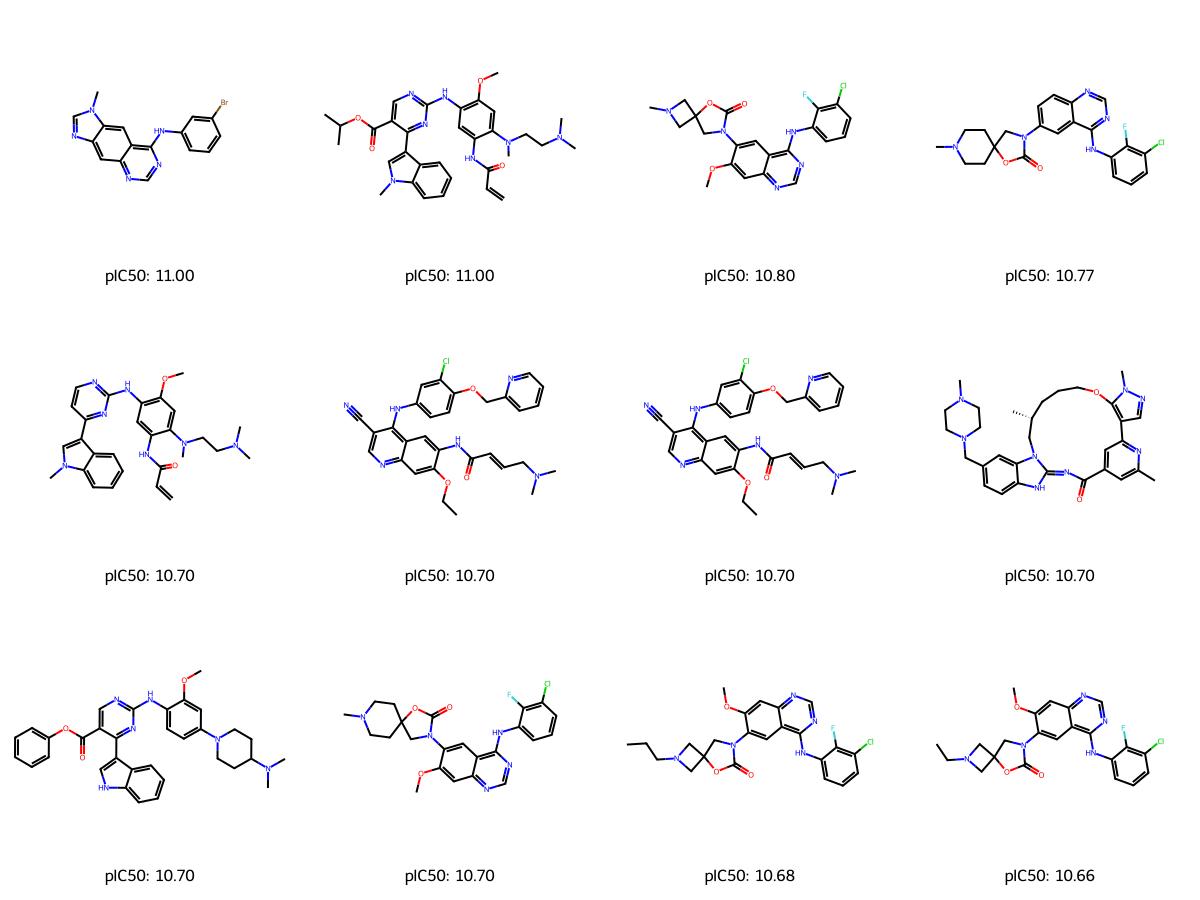

In [22]:
# 1. Zobaczmy, jakie są realne progi aktywności
print(f"Najwyższe pIC50 w zbiorze: {eda_df['pIC50'].max():.2f}")
print(f"Średnie pIC50: {eda_df['pIC50'].mean():.2f}")

# 2. Wybieramy 12 najlepszych cząsteczek ("Hity")
# Nawet jeśli nie są outlierami, to są to Twoi najlepsi kandydaci
top_hits = eda_df.sort("pIC50", descending=True).head(12)

# 3. Rysujemy struktury
mols = [Chem.MolFromSmiles(s) for s in top_hits["canonical_smiles"]]
legends = [f"pIC50: {v:.2f}" for v in top_hits["pIC50"]]

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 300), legends=legends)
display(img)

Wyświetlam 12 najsilniejszych cząsteczek dla Twojego celu:


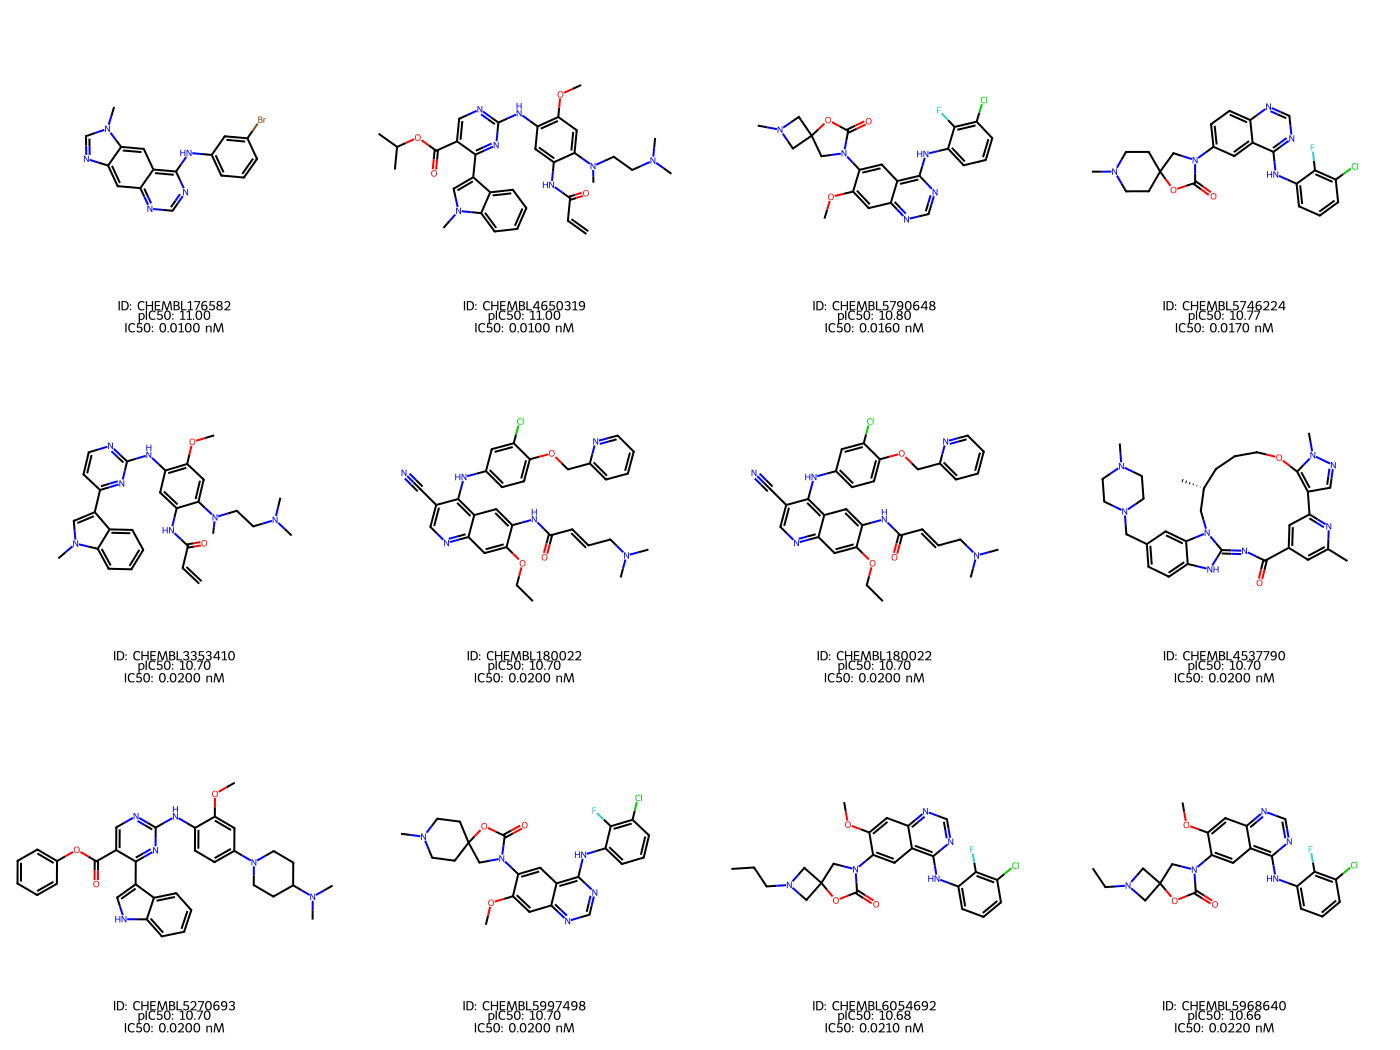

In [23]:

# 1. Wybieramy top 12 cząsteczek
# Sortujemy po pIC50 malejąco (im wyższe, tym silniejszy lek)
top_hits = eda_df.sort("pIC50", descending=True).head(12)

# 2. Przygotowujemy listy do rysowania
mols = []
legends = []

# Iterujemy po wierszach (zamienionych na słowniki dla wygody)
for row in top_hits.to_dicts():
    smiles = row["canonical_smiles"]
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        mols.append(mol)
        # Tworzymy wielolinijkowy podpis (Nazwa + pIC50 + IC50)
        # \n odpowiada za nową linię w podpisie
        legend = (
            f"ID: {row['molecule_chembl_id']}\n"
            f"pIC50: {row['pIC50']:.2f}\n"
            f"IC50: {row['IC50']:.4f} nM"
        )
        legends.append(legend)

# 3. Rysujemy siatkę
# subImgSize=(300, 300) - zwiększam rozmiar, żeby napisy były czytelne
img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=4, 
    subImgSize=(350, 350), 
    legends=legends
)

print(f"Wyświetlam 12 najsilniejszych cząsteczek dla Twojego celu:")
display(img)

#### Scaffoldów (szkieletów Bemis-Murcko)

Generowanie szkieletów dla 18k cząsteczek...
Całkowita liczba unikalnych szkieletów: 3841
Średnia liczba cząsteczek na jeden szkielet: 4.85


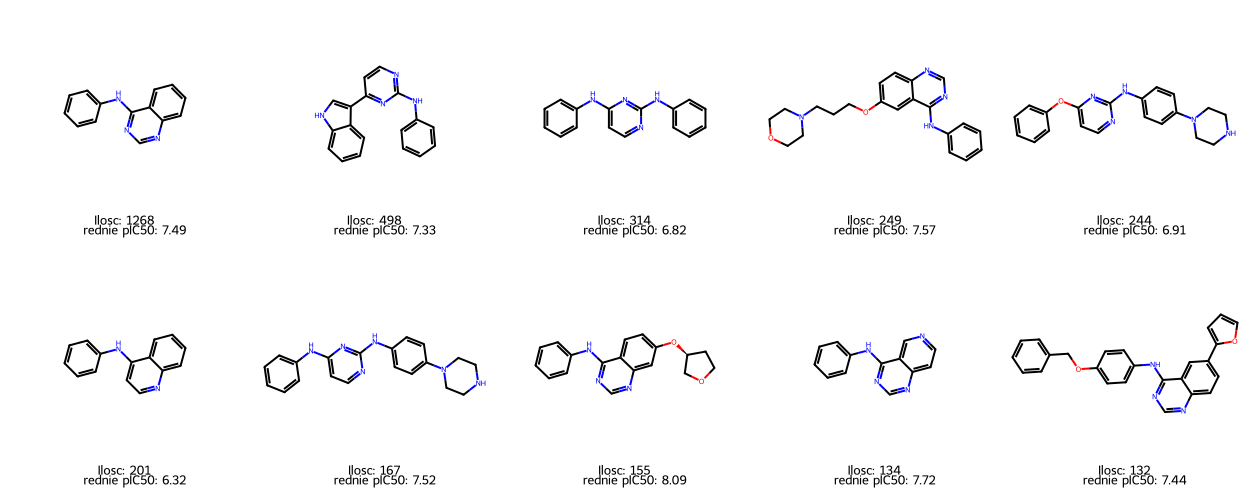

In [24]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
import polars as pl

# 1. Funkcja do wyciągania szkieletu
def get_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Generuje szkielet Bemis-Murcko
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold)
    except:
        return None
    return None

# 2. Obliczamy szkielety dla całego zbioru (może to zająć chwilę)
print("Generowanie szkieletów dla 18k cząsteczek...")
scaffold_data = eda_df.select([
    "canonical_smiles",
    "pIC50"
]).with_columns(
    pl.col("canonical_smiles").map_elements(get_scaffold, return_dtype=pl.Utf8).alias("scaffold_smiles")
)

# 3. Agregacja: liczymy ile razy występuje dany szkielet i jaka jest średnia aktywność
scaffold_stats = scaffold_data.group_by("scaffold_smiles").agg([
    pl.count("scaffold_smiles").alias("count"),
    pl.col("pIC50").mean().alias("avg_pIC50")
]).sort("count", descending=True)

# 4. Wyświetlamy statystyki ogólne
print(f"Całkowita liczba unikalnych szkieletów: {len(scaffold_stats)}")
print(f"Średnia liczba cząsteczek na jeden szkielet: {len(eda_df)/len(scaffold_stats):.2f}")

# 5. Wizualizacja TOP 10 najczęstszych szkieletów
top_scaffolds = scaffold_stats.head(10).to_dicts()
mols = [Chem.MolFromSmiles(s["scaffold_smiles"]) for s in top_scaffolds if s["scaffold_smiles"]]
legends = [f"Ilosc: {s['count']}\nŚrednie pIC50: {s['avg_pIC50']:.2f}" for s in top_scaffolds]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(250, 250), legends=legends)
display(img)

#### Reguła Lipińskiego (Rule of Five)

Obliczanie właściwości fizykochemicznych...


/var/folders/xs/ng936c_15s1831tg8jwvbrqr0000gn/T/ipykernel_11501/1294236634.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lipinski_df.to_pandas(), x="violations", palette="magma", ax=axes[0,1])


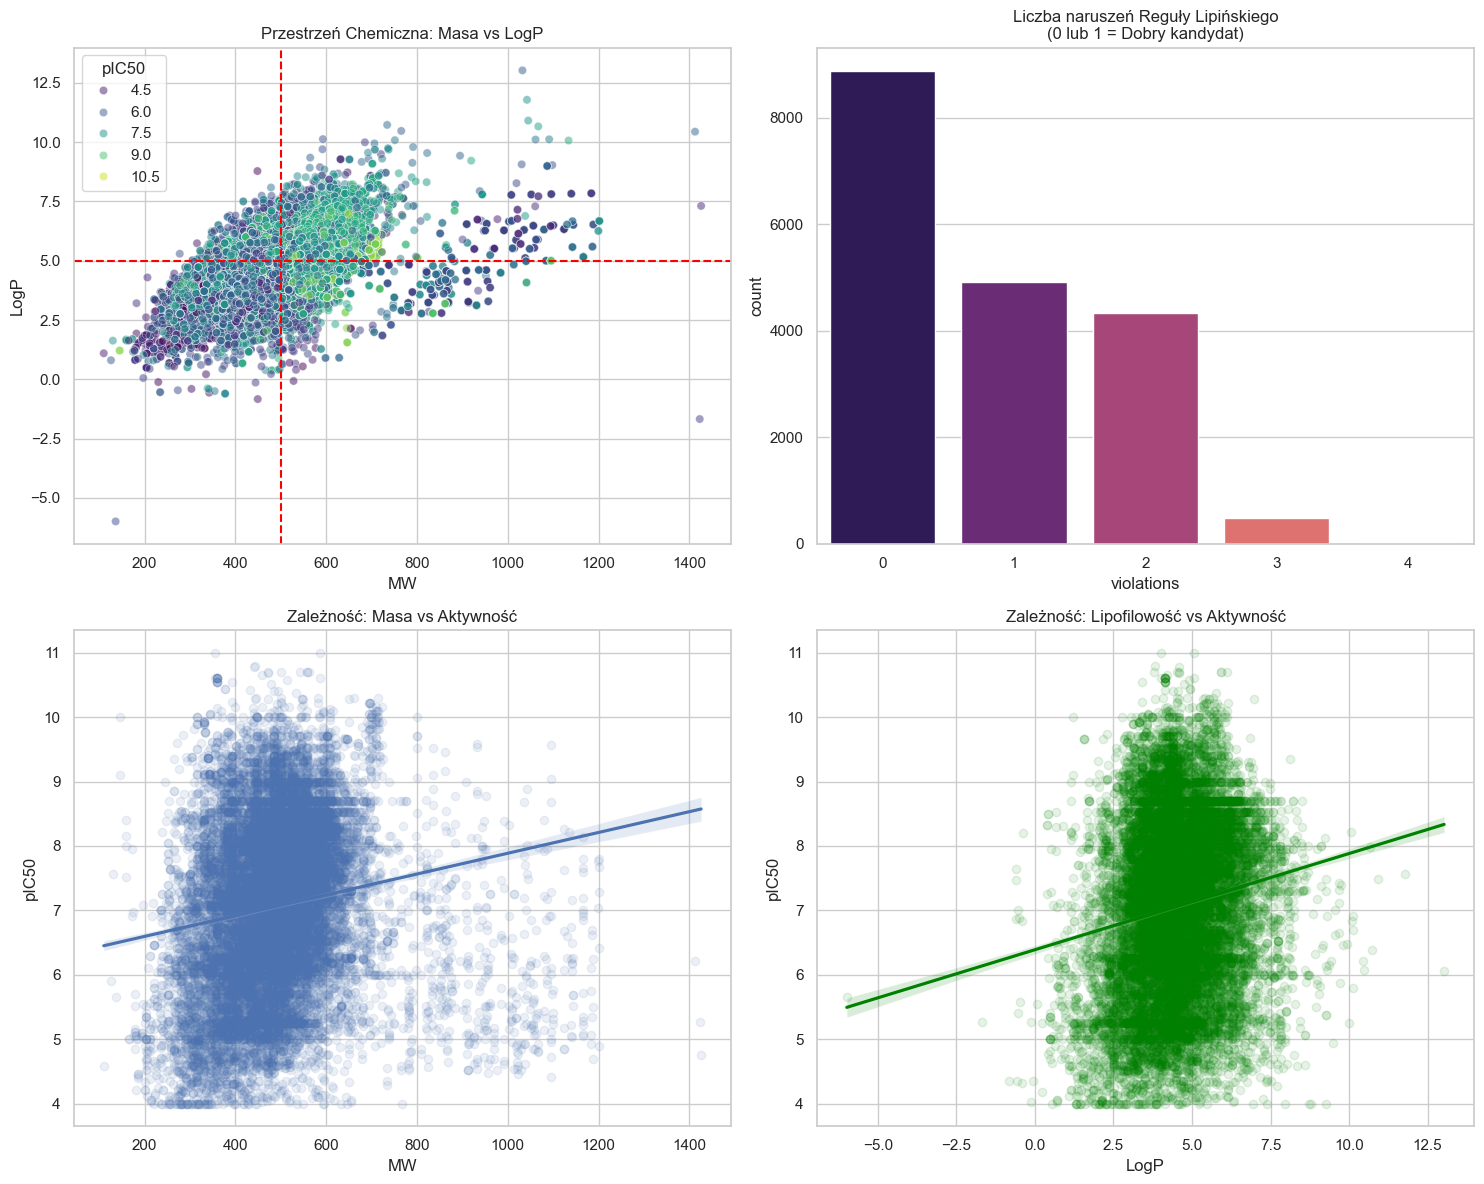

Procent cząsteczek spełniających regułę (0-1 naruszeń): 74.04%


In [25]:
from rdkit.Chem import Descriptors
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Funkcja obliczająca komplet deskryptorów Lipińskiego
def get_lipinski_data(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            "MW": Descriptors.MolWt(mol),
            "LogP": Descriptors.MolLogP(mol),
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol)
        }
    return {"MW": None, "LogP": None, "HBD": None, "HBA": None}

# 2. Mapowanie deskryptorów w Polars
print("Obliczanie właściwości fizykochemicznych...")
# Wyciągamy dane do słownika, a potem do DataFrame
desc_list = [get_lipinski_data(s) for s in eda_df["canonical_smiles"]]
desc_df = pl.from_dicts(desc_list)

# Łączymy z głównym zbiorem
lipinski_df = pl.concat([eda_df, desc_df], how="horizontal").drop_nulls(subset=["MW", "LogP"])

# 3. Sprawdzanie naruszeń reguły
lipinski_df = lipinski_df.with_columns([
    ((pl.col("MW") > 500).cast(pl.Int8) +
     (pl.col("LogP") > 5).cast(pl.Int8) +
     (pl.col("HBD") > 5).cast(pl.Int8) +
     (pl.col("HBA") > 10).cast(pl.Int8)).alias("violations")
])

# 4. WIZUALIZACJA
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# MW vs LogP (Klasyczny wykres w projektowaniu leków)
sns.scatterplot(data=lipinski_df.to_pandas(), x="MW", y="LogP", hue="pIC50", 
                palette="viridis", alpha=0.5, ax=axes[0,0])
axes[0,0].axvline(500, color='red', linestyle='--')
axes[0,0].axhline(5, color='red', linestyle='--')
axes[0,0].set_title("Przestrzeń Chemiczna: Masa vs LogP")

# Rozkład naruszeń
sns.countplot(data=lipinski_df.to_pandas(), x="violations", palette="magma", ax=axes[0,1])
axes[0,1].set_title("Liczba naruszeń Reguły Lipińskiego\n(0 lub 1 = Dobry kandydat)")

# MW vs pIC50
sns.regplot(data=lipinski_df.to_pandas(), x="MW", y="pIC50", scatter_kws={'alpha':0.1}, ax=axes[1,0])
axes[1,0].set_title("Zależność: Masa vs Aktywność")

# LogP vs pIC50
sns.regplot(data=lipinski_df.to_pandas(), x="LogP", y="pIC50", scatter_kws={'alpha':0.1}, ax=axes[1,1], color="green")
axes[1,1].set_title("Zależność: Lipofilowość vs Aktywność")

plt.tight_layout()
plt.show()

print(f"Procent cząsteczek spełniających regułę (0-1 naruszeń): "
      f"{(len(lipinski_df.filter(pl.col('violations') <= 1)) / len(lipinski_df)) * 100:.2f}%")

## Data Cleaning